In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df=pd.read_csv("advertising.csv")

In [7]:
df.head()
# this data represent money spent on adv on TV Radio and Newspaper and amount of sales recorded


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [8]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [10]:
df.shape

(200, 4)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


# visualization

array([[<Axes: title={'center': 'TV'}>,
        <Axes: title={'center': 'Radio'}>],
       [<Axes: title={'center': 'Newspaper'}>, <Axes: >]], dtype=object)

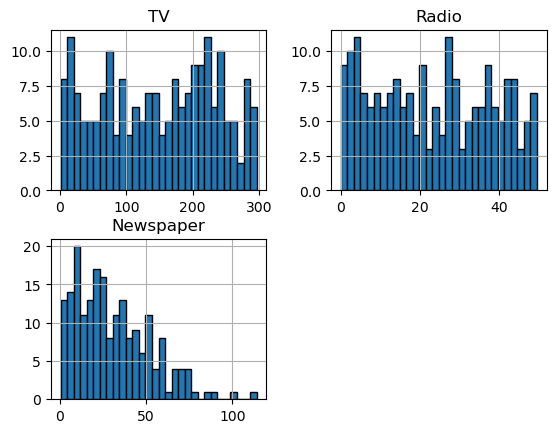

In [17]:
df.drop("Sales",axis=1).hist(bins=30,edgecolor="black")

Text(0.5, 1.0, 'Newspaper vs Sales')

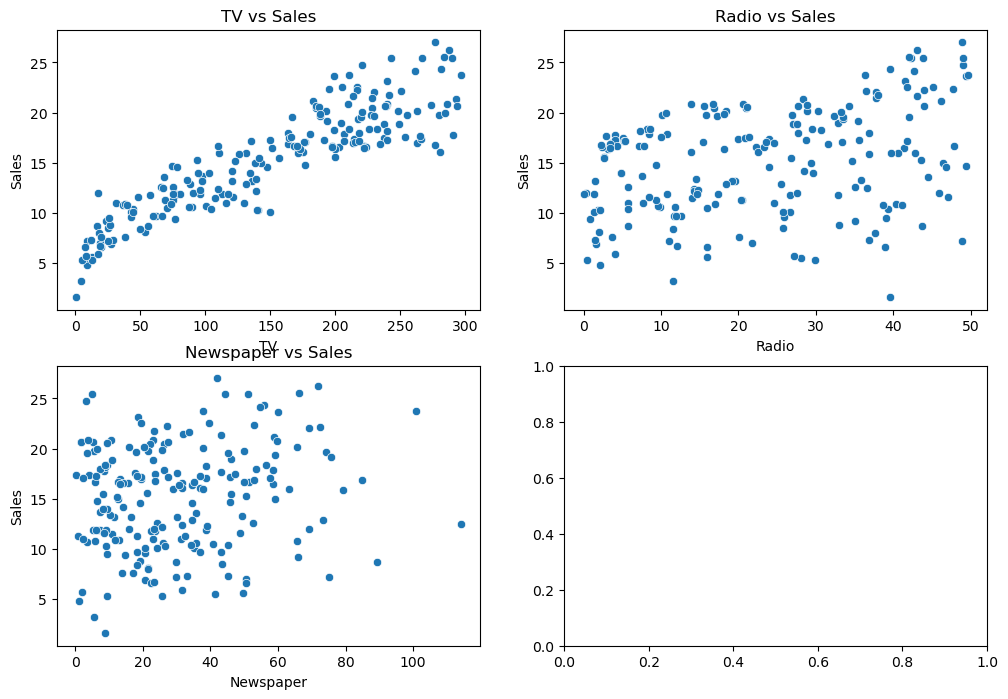

In [26]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
sns.scatterplot(data=df,x="TV",y="Sales",ax=axes[0,0])
axes[0,0].set_title("TV vs Sales")


sns.scatterplot(data=df,x="Radio",y="Sales",ax=axes[0,1])
axes[0,1].set_title("Radio vs Sales")  


sns.scatterplot(data=df,x="Newspaper",y="Sales",ax=axes[1,0])
axes[1,0].set_title("Newspaper vs Sales")




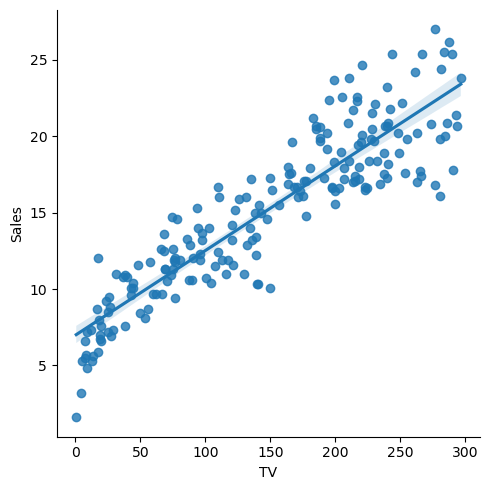

In [27]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.lmplot(data=df, x="TV", y="Sales")   # scatter + regression line
# plt.show()


<Axes: >

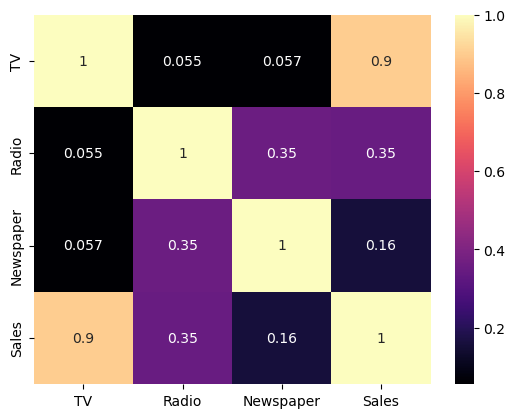

In [33]:
corr_mat=df.corr()
sns.heatmap(corr_mat,cmap="magma",annot=True)

# model training and evaluation

In [35]:
from sklearn.model_selection import train_test_split
X=df.drop("Sales",axis=1)
y=df["Sales"]
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)


In [38]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_pred=lr.predict(x_test)

In [42]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MSE",mean_squared_error(y_test,y_pred))
print("MAE",mean_absolute_error(y_test,y_pred))
print("r2_score",r2_score(y_test,y_pred))

MSE 2.907756910271092
MAE 1.274826210954934
r2_score 0.9059011844150826


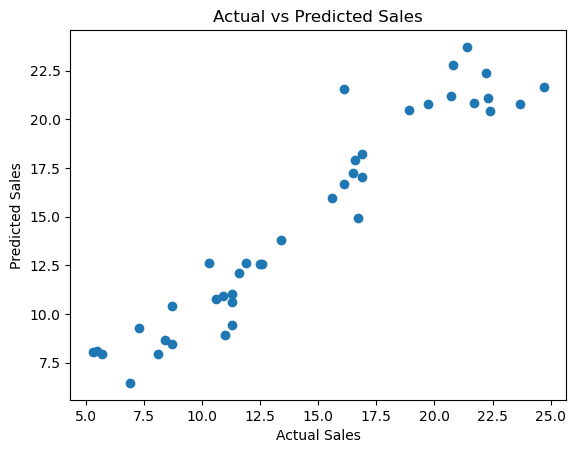

In [43]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()